In [425]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple, List

## Лабораторная работа №2

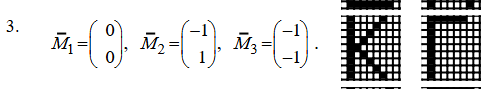

In [426]:
def linear_boundary(M1: np.ndarray, M2: np.ndarray, B: np.ndarray, 
                   threshold: float, x_range: Tuple[float, float], n_points: int = 200) -> Tuple[np.ndarray, np.ndarray]:
    """Строит линейную разделяющую границу для нормальных распределений с равными ковариациями"""
    x_min, x_max = x_range
    x = np.linspace(x_min, x_max, n_points)
    
    B_inv = np.linalg.inv(B)
    a = (M1 - M2).T @ B_inv
    b = -0.5 * (M1 + M2).T @ B_inv @ (M1 - M2) + threshold
    
    y = (-a[0] * x - b) / a[1]
    return x, y

In [427]:
def Bayes_Classifier(M1: np.ndarray, M2: np.ndarray, B: np.ndarray, 
                    x_range: Tuple[float, float], prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    """Байесовский классификатор"""
    threshold = np.log(prob1 / prob2)
    return linear_boundary(M1, M2, B, threshold, x_range)

In [428]:
def compute_error_probabilities(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    """Вычисляет вероятности ошибок классификации"""
    threshold = np.log(prob1 / prob2)
    
    err_I = 1 - norm.cdf((threshold + 0.5 * dist) / np.sqrt(dist))
    err_II = norm.cdf((threshold - 0.5 * dist) / np.sqrt(dist))
    total_err = prob1 * err_I + prob2 * err_II
    
    return err_I, err_II, total_err

In [429]:
def compute_errors_no_aprior_probs(dist: float, threshold: float):
    """Вычисляет вероятности ошибок классификации для случая когда априорные вероятности не заданы"""
    err_I = 1 - norm.cdf((threshold + 0.5 * dist) / np.sqrt(dist))
    err_II = norm.cdf((threshold - 0.5 * dist) / np.sqrt(dist))
    
    return err_I, err_II

In [430]:
def experimental_error_rate(X_test: np.ndarray, true_class: int, 
                          M_list: List[np.ndarray], B_list: List[np.ndarray],
                          probs: List[float]) -> float:
    """Экспериментальная оценка вероятности ошибки"""
    errors = 0
    for x in X_test:
        # Вычисляем дискриминантные функции для всех классов
        d_values = []
        for M, B, p in zip(M_list, B_list, probs):
            B_inv = np.linalg.inv(B)
            d = -0.5 * (x - M).T @ B_inv @ (x - M) - 0.5 * np.log(np.linalg.det(B)) + np.log(p)
            d_values.append(d)
        
        # Классифицируем в класс с максимальной дискриминантной функцией
        pred_class = np.argmax(d_values)
        if pred_class != true_class:
            errors += 1
    
    return errors / len(X_test)

In [431]:
def mahalanobis_distance(M1: np.ndarray, M2: np.ndarray, B: np.ndarray) -> float:
    """Вычисляет расстояние Махаланобиса между центрами классов"""
    delta = M1 - M2
    B_inv = np.linalg.inv(B)
    return np.sqrt(delta.T @ B_inv @ delta)

In [432]:
def quadratic_boundary(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2: np.ndarray, 
                      prob1: float, prob2: float, x_range: Tuple[float, float], 
                      y_range: Tuple[float, float], n_points: int = 300) -> np.ndarray:
    """Строит квадратичную разделяющую границу для неравных ковариаций"""
    x_min, x_max = x_range
    y_min, y_max = y_range
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_points),
                         np.linspace(y_min, y_max, n_points))
    
    B1_inv = np.linalg.inv(B1)
    B2_inv = np.linalg.inv(B2)
    
    # Дискриминантные функции для двух классов
    Z = np.zeros_like(xx)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            x = np.array([xx[i,j], yy[i,j]])
            
            # d1(x) - d2(x) = 0 (граница между классами 1 и 2)
            d1 = -0.5 * (x - M1).T @ B1_inv @ (x - M1) - 0.5 * np.log(np.linalg.det(B1)) + np.log(prob1)
            d2 = -0.5 * (x - M2).T @ B2_inv @ (x - M2) - 0.5 * np.log(np.linalg.det(B2)) + np.log(prob2)
            
            Z[i,j] = d1 - d2
    
    return xx, yy, Z

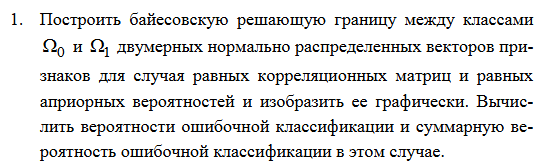

In [433]:
# Загрузка данных
X1 = np.load("data/X1_equal_cov.npy")
X2 = np.load("data/X2_equal_cov.npy")

# Оценка параметров
M1_est = np.mean(X1, axis=0)
M2_est = np.mean(X2, axis=0)
B_est = (np.cov(X1.T) + np.cov(X2.T)) / 2

# Параметры классификатора
prob1, prob2 = 0.5, 0.5  # равные априорные вероятности
x_range = (min(X1[:,0].min(), X2[:,0].min()) - 0.5, 
           max(X1[:,0].max(), X2[:,0].max()) + 0.5)

# Вычисление характеристик
dist = mahalanobis_distance(M1_est, M2_est, B_est)
err_I, err_II, total_err = compute_error_probabilities(dist, prob1, prob2)

# Построение байесовской границы
x_bayes, y_bayes = Bayes_Classifier(M1_est, M2_est, B_est, x_range, prob1, prob2)

print(f"\nРасстояние Махаланобиса: {dist:.4f}")
print(f"\nВероятности ошибок:")
print(f"p₀₁ (ошибка I рода): {err_I:.4f}")
print(f"p₁₀ (ошибка II рода): {err_II:.4f}")
print(f"Общая вероятность ошибки: {total_err:.4f}")


Расстояние Махаланобиса: 2.0694

Вероятности ошибок:
p₀₁ (ошибка I рода): 0.2360
p₁₀ (ошибка II рода): 0.2360
Общая вероятность ошибки: 0.2360


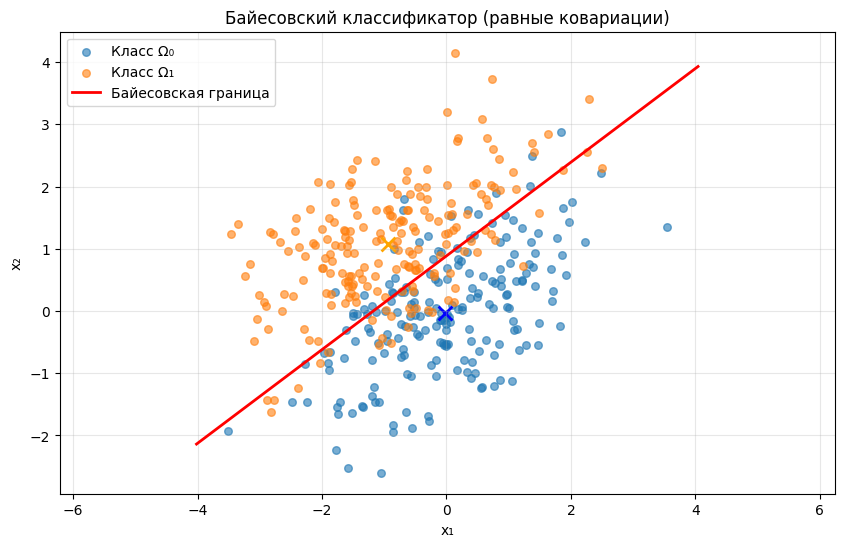

In [434]:
plt.figure(figsize=(10, 6))
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label='Класс Ω₀', s=30)
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.6, label='Класс Ω₁', s=30)
plt.plot(x_bayes, y_bayes, 'r-', linewidth=2, label='Байесовская граница')
plt.scatter(M1_est[0], M1_est[1], color='blue', marker='x', s=100, linewidth=2)
plt.scatter(M2_est[0], M2_est[1], color='orange', marker='x', s=100, linewidth=2)

plt.xlabel('x₁'); plt.ylabel('x₂')
plt.title('Байесовский классификатор (равные ковариации)')
plt.legend(); plt.grid(True, alpha=0.3); plt.axis('equal')
plt.show()

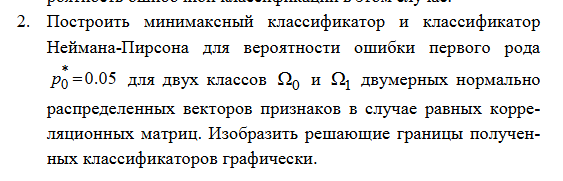

In [435]:
def MinMax_Classifier(M1: np.ndarray, M2: np.ndarray, B: np.ndarray,
                     x_range: Tuple[float, float]) -> Tuple[np.ndarray, np.ndarray]:
    """Минимаксный классификатор"""
    return linear_boundary(M1, M2, B, 0, x_range)

def NeymanPearson_Classifier(M1: np.ndarray, M2: np.ndarray, B: np.ndarray,
                            x_range: Tuple[float, float], p0: float, dist: float) -> Tuple[np.ndarray, np.ndarray]:
    """Классификатор Неймана-Пирсона"""
    lambda_ln = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0)
    return linear_boundary(M1, M2, B, lambda_ln, x_range)

In [436]:
dist = mahalanobis_distance(M1_est, M2_est, B_est)
p0_target = 0.05

# Построение классификаторов
x_minmax, y_minmax = MinMax_Classifier(M1_est, M2_est, B_est, x_range)
x_np, y_np = NeymanPearson_Classifier(M1_est, M2_est, B_est, x_range, p0_target, dist)

# Вычисление вероятностей ошибок
err_I_minmax, err_II_minmax = compute_errors_no_aprior_probs(dist, 0)
lambda_np = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0_target)
err_I_np, err_II_np = compute_errors_no_aprior_probs(dist, lambda_np)

(np.float64(-4.420284524900264),
 np.float64(4.445714255546486),
 np.float64(-2.953179639989104),
 np.float64(4.843585197332901))

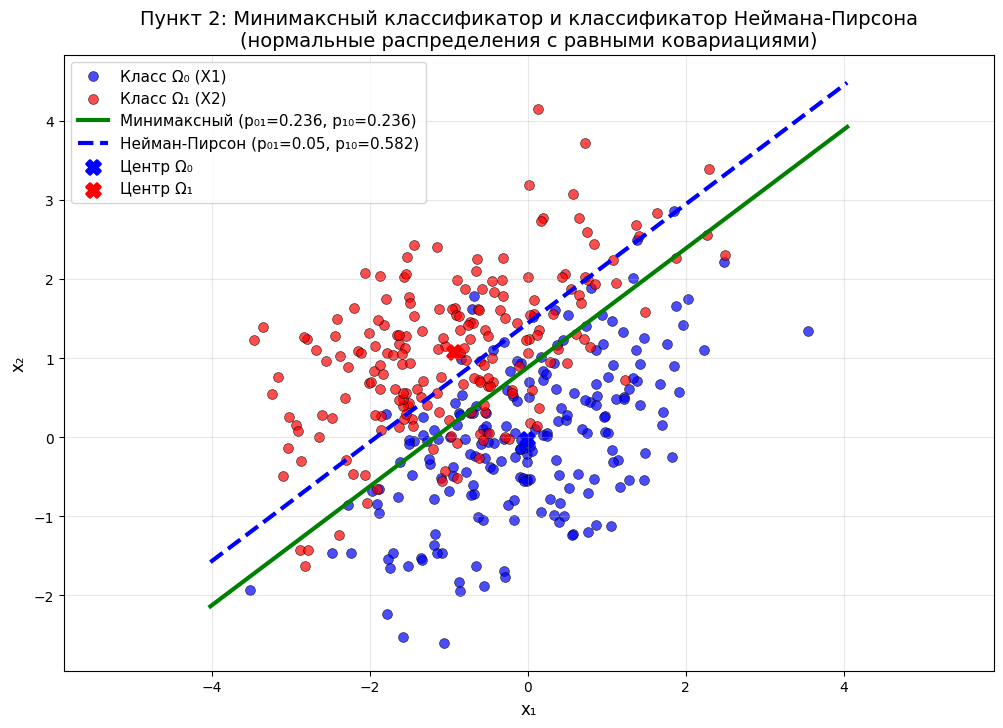

In [437]:

# Сводный график для пункта 2
plt.figure(figsize=(12, 8))

# Данные
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.7, label='Класс Ω₀ (X1)', s=50, color='blue', edgecolors='black', linewidth=0.5)
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7, label='Класс Ω₁ (X2)', s=50, color='red', edgecolors='black', linewidth=0.5)

# Границы классификаторов
plt.plot(x_minmax, y_minmax, 'g-', linewidth=3, label=f'Минимаксный (p₀₁={err_I_minmax:.3f}, p₁₀={err_II_minmax:.3f})')
plt.plot(x_np, y_np, 'b--', linewidth=3, label=f'Нейман-Пирсон (p₀₁={p0_target}, p₁₀={err_II_np:.3f})')

# Центры классов
plt.scatter(M1_est[0], M1_est[1], color='blue', marker='X', s=100, linewidth=2, label='Центр Ω₀')
plt.scatter(M2_est[0], M2_est[1], color='red', marker='X', s=100, linewidth=2, label='Центр Ω₁')

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Пункт 2: Минимаксный классификатор и классификатор Неймана-Пирсона\n(нормальные распределения с равными ковариациями)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')

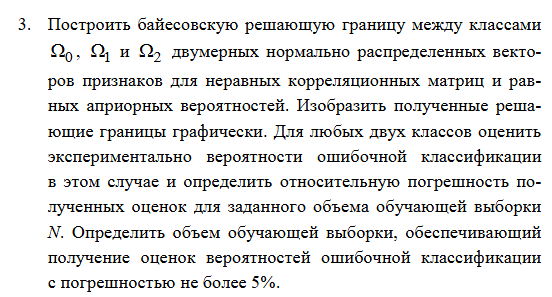

In [438]:
X1_unequal = np.load("data/X1_unequal_cov.npy")  # Класс Ω₀
X2_unequal = np.load("data/X2_unequal_cov.npy")  # Класс Ω₁  
X3_unequal = np.load("data/X3_unequal_cov.npy")  # Класс Ω₂

M1 = np.array([0.0, 0.0])
M2 = np.array([-1.0, 1.0])
M3 = np.array([-1.0, -1.0])

N = 200

# Красивые ковариационные матрицы с разной ориентацией и формой:
B1 = np.array([[0.2, -0.1],
               [-0.1, 0.4]])

B2 = np.array([[0.4, -0.2],
               [-0.2, 0.4]])

B3 = np.array([[0.3, -0.05],
               [-0.05, 0.3]])

# Равные априорные вероятности
probs = [1/3, 1/3, 1/3]

# Определяем область построения
x_min = min(X1_unequal[:,0].min(), X2_unequal[:,0].min(), X3_unequal[:,0].min()) - 0.5
x_max = max(X1_unequal[:,0].max(), X2_unequal[:,0].max(), X3_unequal[:,0].max()) + 0.5
y_min = min(X1_unequal[:,1].min(), X2_unequal[:,1].min(), X3_unequal[:,1].min()) - 0.5
y_max = max(X1_unequal[:,1].max(), X2_unequal[:,1].max(), X3_unequal[:,1].max()) + 0.5

# Построение разделяющих границ
xx12, yy12, Z12 = quadratic_boundary(M1, M2, B1, B2, probs[0], probs[1], (x_min, x_max), (y_min, y_max))
xx13, yy13, Z13 = quadratic_boundary(M1, M3, B1, B3, probs[0], probs[2], (x_min, x_max), (y_min, y_max))
xx23, yy23, Z23 = quadratic_boundary(M2, M3, B2, B3, probs[1], probs[2], (x_min, x_max), (y_min, y_max))

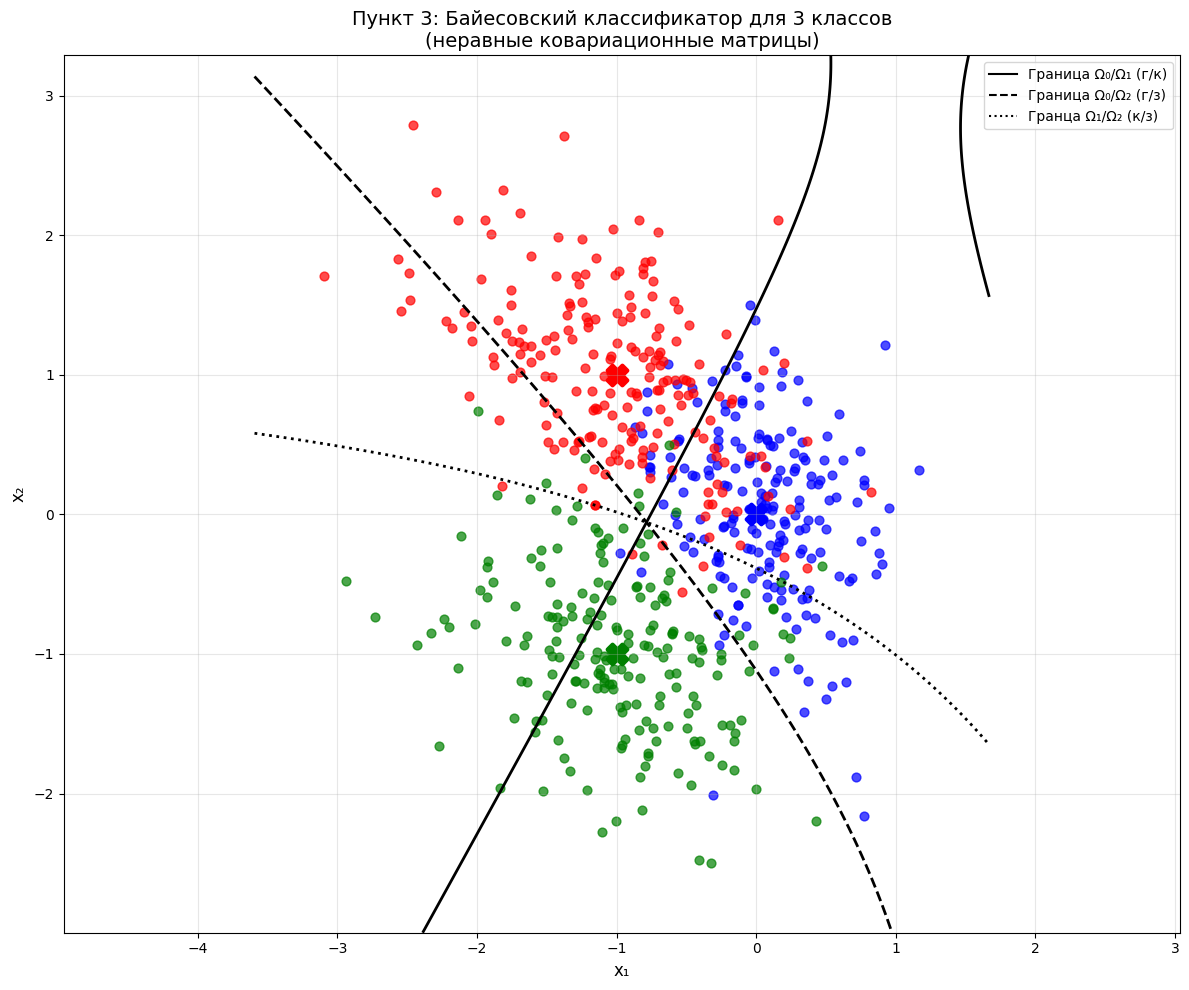

In [439]:
plt.figure(figsize=(12, 10))

# Данные
plt.scatter(X1_unequal[:, 0], X1_unequal[:, 1], alpha=0.7, label='Класс Ω₀', s=40, color='blue')
plt.scatter(X2_unequal[:, 0], X2_unequal[:, 1], alpha=0.7, label='Класс Ω₁', s=40, color='red')
plt.scatter(X3_unequal[:, 0], X3_unequal[:, 1], alpha=0.7, label='Класс Ω₂', s=40, color='green')

# Разделяющие границы (квадратичные)
plt.contour(xx12, yy12, Z12, levels=[0], colors='black', linewidths=2, linestyles='-')
plt.contour(xx13, yy13, Z13, levels=[0], colors='black', linewidths=2, linestyles='--') 
plt.contour(xx23, yy23, Z23, levels=[0], colors='black', linewidths=2, linestyles=':')

plt.scatter(M1[0], M1[1], color='blue', marker='X', s=200, linewidth=3, label='Центр Ω₀')
plt.scatter(M2[0], M2[1], color='red', marker='X', s=200, linewidth=3, label='Центр Ω₁')
plt.scatter(M3[0], M3[1], color='green', marker='X', s=200, linewidth=3, label='Центр Ω₂')

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Пункт 3: Байесовский классификатор для 3 классов\n(неравные ковариационные матрицы)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Легенда для границ
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='Граница Ω₀/Ω₁ (г/к)'),
    Line2D([0], [0], color='black', linestyle='--', label='Граница Ω₀/Ω₂ (г/з)'),
    Line2D([0], [0], color='black', linestyle=':', label='Гранца Ω₁/Ω₂ (к/з)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [440]:
# Оценка ошибок для каждой пары классов
N = len(X1_unequal)  # объем выборки

# Ошибки для класса Ω₀
error_0 = experimental_error_rate(X1_unequal, 0, [M1, M2, M3], [B1, B2, B3], probs)

# Ошибки для класса Ω₁  
error_1 = experimental_error_rate(X2_unequal, 1, [M1, M2, M3], [B1, B2, B3], probs)

# Ошибки для класса Ω₂
error_2 = experimental_error_rate(X3_unequal, 2, [M1, M2, M3], [B1, B2, B3], probs)

# Общая вероятность ошибки
total_error = (error_0 + error_1 + error_2) / 3

print(f"Вероятность ошибки для класса Ω₀: {error_0:.4f}")
print(f"Вероятность ошибки для класса Ω₁: {error_1:.4f}") 
print(f"Вероятность ошибки для класса Ω₂: {error_2:.4f}")
print(f"Общая вероятность ошибки: {total_error:.4f}")

Вероятность ошибки для класса Ω₀: 0.1150
Вероятность ошибки для класса Ω₁: 0.1800
Вероятность ошибки для класса Ω₂: 0.0900
Общая вероятность ошибки: 0.1283


In [441]:
def required_sample_size(p_error: float, max_error: float = 0.05) -> int:
    """Определяет объем выборки для заданной точности оценки"""
    if p_error == 0:
        return int(1 / (max_error ** 2))
    
    relative_error = np.sqrt((1 - p_error) / (p_error))
    N = (relative_error / max_error) ** 2
    return int(np.ceil(N))

print(f"\nОпределение требуемого объема выборки для ε ≤ 5%")
for p, class_name in zip([error_0, error_1, error_2], ['Ω₀', 'Ω₁', 'Ω₂']):
    N_req = required_sample_size(p, 0.05)
    print(f"Класс {class_name}: p̂ = {p:.4f} → N ≥ {N_req}")

# Для общей ошибки
N_total_req = required_sample_size(total_error, 0.05)
print(f"Общая ошибка: p̂ = {total_error:.4f} → N ≥ {N_total_req}")

print(f"\nТекущий объем выборки: N = {N}")
print(f"Рекомендуемый объем для точности 5%: N ≥ {max(required_sample_size(total_error, 0.05), 1000)}")


Определение требуемого объема выборки для ε ≤ 5%
Класс Ω₀: p̂ = 0.1150 → N ≥ 3079
Класс Ω₁: p̂ = 0.1800 → N ≥ 1823
Класс Ω₂: p̂ = 0.0900 → N ≥ 4045
Общая ошибка: p̂ = 0.1283 → N ≥ 2717

Текущий объем выборки: N = 200
Рекомендуемый объем для точности 5%: N ≥ 2717
